In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display full columns
pd.set_option('display.max_columns', None)

In [2]:
# Load datasets

matches=pd.read_csv("../Datasets/matches.csv",low_memory=False)
deliveries=pd.read_csv("../Datasets/deliveries.csv",low_memory=False)


In [3]:
# Show first rows of matches
matches.head()


,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
# Show first rows of deliveries
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [8]:
print("Matches Columns:")
print(matches.columns.tolist())

print("\nDeliveries Columns:")
print(deliveries.columns.tolist())

Matches Columns:
['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries Columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [9]:
print("Missing Values in Matches:")
print(matches.isnull().sum())

Missing Values in Matches:
match_id              0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [10]:
print("Missing Values in Deliveries:")
print(deliveries.isnull().sum())

Missing Values in Deliveries:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [11]:
print("Duplicate rows in matches:", matches.duplicated().sum())
print("Duplicate rows in deliveries:", deliveries.duplicated().sum())

Duplicate rows in matches: 0
Duplicate rows in deliveries: 0


In [12]:
print("Seasons Available:")
print(sorted(matches["season"].unique()))

Seasons Available:
['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


In [13]:
teams_match = set(matches["team1"].unique()) | set(matches["team2"].unique())

teams_delivery = set(deliveries["batting_team"].unique()) | set(deliveries["bowling_team"].unique())

print("Teams in matches dataset:")
print(sorted(teams_match))

print("\nTeams in deliveries dataset:")
print(sorted(teams_delivery))

Teams in matches dataset:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Teams in deliveries dataset:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [14]:
print("Toss Decisions:")
print(matches["toss_decision"].unique())

Toss Decisions:
['field' 'bat']


In [15]:
print("Winner Unique Values:")
print(sorted(matches["winner"].dropna().unique()))

Winner Unique Values:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [16]:
print("Total Venues:", matches["venue"].nunique())

print(sorted(matches["venue"].unique()))

Total Venues: 58
['Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi', 'Barabati Stadium', 'Barsapara Cricket Stadium, Guwahati', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium', 'Brabourne Stadium, Mumbai', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Mumbai', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Eden Gardens, Kolkata', 'Feroz Shah Kotla', 'Green Park', 'Himachal Pradesh Cricket Association Stadium', 'Himachal Pradesh Cricket Association Stadium, Dharamsala', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru', 'M.Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium, Chepauk, Chennai', 'Maharaja Yadavindra 

In [17]:
print("Cities:")
print(sorted(matches["city"].dropna().unique()))

Cities:
['Abu Dhabi', 'Ahmedabad', 'Bangalore', 'Bengaluru', 'Bloemfontein', 'Cape Town', 'Centurion', 'Chandigarh', 'Chennai', 'Cuttack', 'Delhi', 'Dharamsala', 'Dubai', 'Durban', 'East London', 'Guwahati', 'Hyderabad', 'Indore', 'Jaipur', 'Johannesburg', 'Kanpur', 'Kimberley', 'Kochi', 'Kolkata', 'Lucknow', 'Mohali', 'Mumbai', 'Nagpur', 'Navi Mumbai', 'Port Elizabeth', 'Pune', 'Raipur', 'Rajkot', 'Ranchi', 'Sharjah', 'Visakhapatnam']


In [18]:
print("Match Types:")
print(matches["match_type"].unique())

Match Types:
['League' 'Semi Final' 'Final' '3rd Place Play-Off' 'Qualifier 1'
 'Elimination Final' 'Qualifier 2' 'Eliminator']


In [19]:
# Convert date column to datetime

matches["date"] = pd.to_datetime(matches["date"])

# Extract year

matches["year"] = matches["date"].dt.year

# Verify

matches[["date","year"]].head()

C:\Users\Akash\AppData\Local\Temp\ipykernel_25916\1703310480.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches["date"] = pd.to_datetime(matches["date"])


,date,year
0,2008-04-18,2008
1,2008-04-19,2008
2,2008-04-19,2008
3,2008-04-20,2008
4,2008-04-20,2008


In [20]:
print("Result Types:")
arr=matches["result"].unique()
for i in arr:
    print(i)

Result Types:
runs
wickets
tie
no result


In [21]:
print("Super Over Values:")
print(matches["super_over"].unique())

Super Over Values:
['N' 'Y']


In [22]:
print("Top Players of Match:")

matches["player_of_match"].value_counts().head(10)

Top Players of Match:


player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64

In [23]:
matches["target_runs"].describe()

count    1092.000000
mean      165.684066
std        33.427048
min        43.000000
25%       146.000000
50%       166.000000
75%       187.000000
max       288.000000
Name: target_runs, dtype: float64

In [24]:
print("Result Margin Summary:")

matches["result_margin"].describe()

Result Margin Summary:


count    1076.000000
mean       17.259294
std        21.787444
min         1.000000
25%         6.000000
50%         8.000000
75%        20.000000
max       146.000000
Name: result_margin, dtype: float64

In [25]:
print("Missing Target Runs:")

matches["target_runs"].isnull().sum()

Missing Target Runs:


np.int64(3)

In [26]:
matches[
    matches["target_runs"].isnull()
].head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,year
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker,2011
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak,2015
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan,2023


In [27]:
print("Super Over Matches:")

matches["super_over"].value_counts()

Super Over Matches:


super_over
N    1081
Y      14
Name: count, dtype: int64

In [28]:
print("Dismissal Types:")

deliveries["dismissal_kind"].value_counts()

Dismissal Types:


dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

In [29]:
matches["player_of_match"].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64

In [30]:
print(
    deliveries["over"].min(),
    deliveries["over"].max()
)

0 19


In [31]:
print(
    deliveries["ball"].min(),
    deliveries["ball"].max()
)

1 11


In [32]:
# Unique value counts for matches

for col in matches.columns:
    
    print(col)
    
    print(matches[col].nunique())
    
    print("----------------")

match_id
1095
----------------
season
17
----------------
city
36
----------------
date
823
----------------
match_type
8
----------------
player_of_match
291
----------------
venue
58
----------------
team1
19
----------------
team2
19
----------------
toss_winner
19
----------------
toss_decision
2
----------------
winner
19
----------------
result
4
----------------
result_margin
98
----------------
target_runs
170
----------------
target_overs
15
----------------
super_over
2
----------------
method
1
----------------
umpire1
62
----------------
umpire2
62
----------------
year
17
----------------


In [33]:
print("Innings Unique Values:")
print(deliveries["inning"].unique())

Innings Unique Values:
[1 2 3 4 5 6]


In [34]:
print("Over Range:")
print(deliveries["over"].min(), "to", deliveries["over"].max())

Over Range:
0 to 19


In [35]:
print("Ball Range:")
print(deliveries["ball"].min(), "to", deliveries["ball"].max())

Ball Range:
1 to 11


In [36]:
print("Batsman Runs Unique:")
print(sorted(deliveries["batsman_runs"].unique()))

Batsman Runs Unique:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [37]:
print("Extras Types:")
print(deliveries["extras_type"].unique())

Extras Types:
['legbyes' nan 'wides' 'byes' 'noballs' 'penalty']


In [38]:
print("Wicket Values:")
print(deliveries["is_wicket"].unique())

Wicket Values:
[0 1]


In [39]:
match_ids_matches = set(matches["match_id"])

match_ids_deliveries = set(deliveries["match_id"])

missing_ids = match_ids_deliveries - match_ids_matches

print("Missing Match IDs:", len(missing_ids))

Missing Match IDs: 0


In [40]:
matches.describe()

,match_id,date,result_margin,target_runs,target_overs,year
count,1.095000e+03,1095,1076.000000,1092.000000,1092.000000,1095.000000
mean,9.048283e+05,2016-06-25 11:39:36.986301184,17.259294,165.684066,19.759341,2016.126027
min,3.359820e+05,2008-04-18 00:00:00,1.000000,43.000000,5.000000,2008.000000
25%,5.483315e+05,2012-04-21 00:00:00,6.000000,146.000000,20.000000,2012.000000
50%,9.809610e+05,2016-05-03 00:00:00,8.000000,166.000000,20.000000,2016.000000
75%,1.254062e+06,2021-04-13 12:00:00,20.000000,187.000000,20.000000,2021.000000
max,1.426312e+06,2024-05-26 00:00:00,146.000000,288.000000,20.000000,2024.000000
std,3.677402e+05,NaN,21.787444,33.427048,1.581108,4.946940


In [41]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


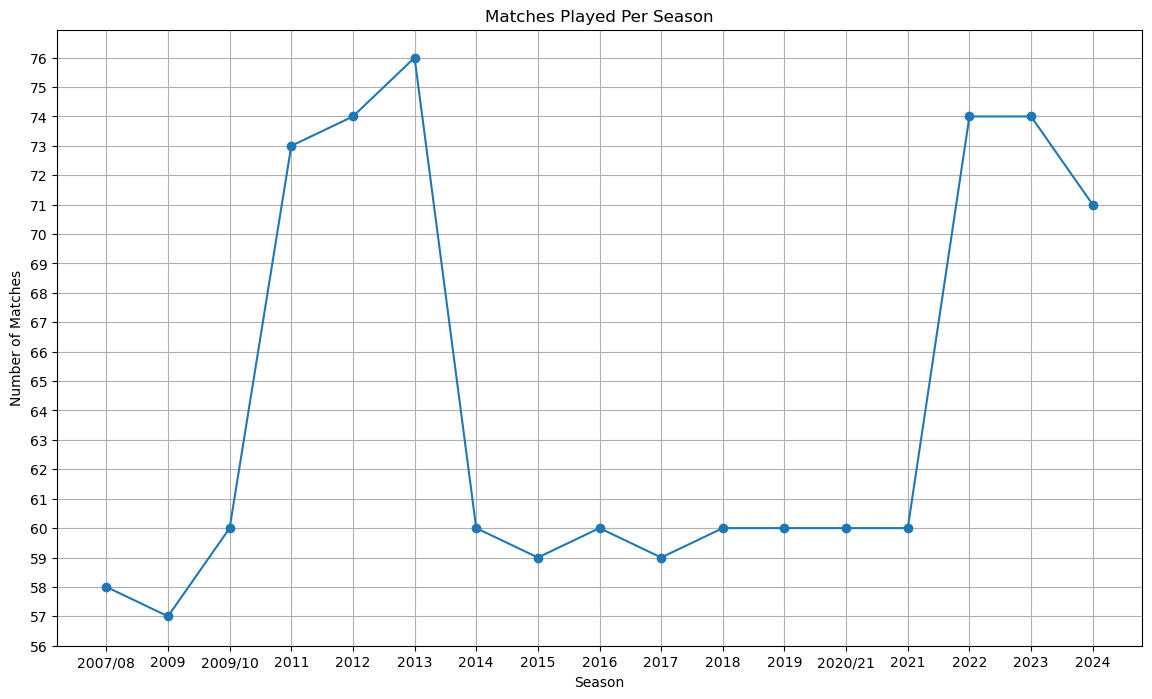

In [42]:
season_matches = matches.groupby("season")["match_id"].count()

plt.figure(figsize=(14,8))

plt.plot(
    season_matches.index,
    season_matches.values,
    marker="o"
)

plt.title("Matches Played Per Season")

plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.yticks(range(int(min(season_matches.values)-1),
                 int(max(season_matches.values))+1))
plt.grid()
# plt.savefig("../images/matches_per_season.png", dpi=300)
plt.show()

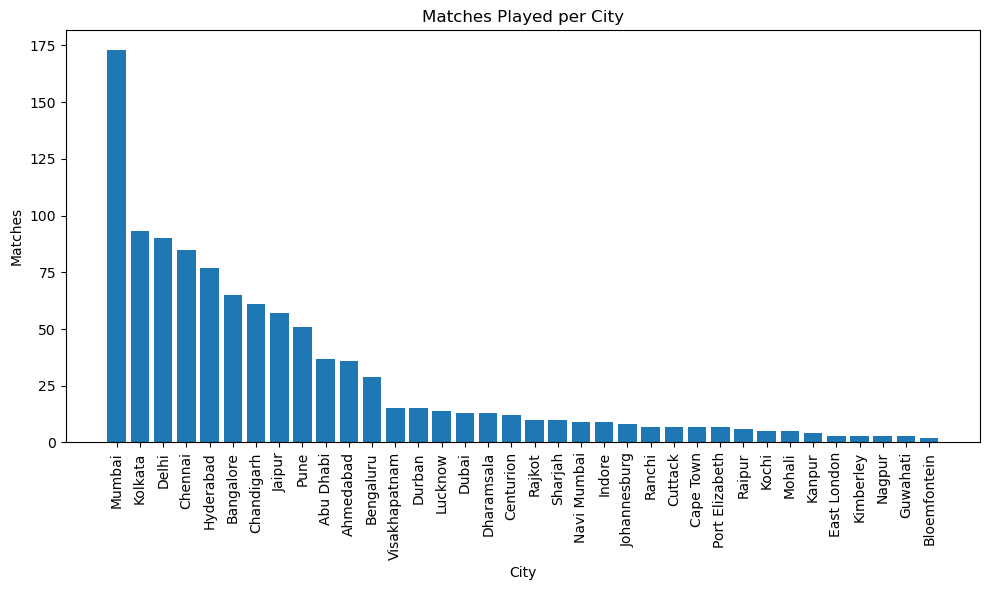

In [43]:
city_matches = matches["city"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(
    city_matches.index,
    city_matches.values
)

plt.xticks(rotation=90)

plt.title("Matches Played per City")

plt.xlabel("City")
plt.ylabel("Matches")

plt.tight_layout()
plt.savefig("../images/matches_per_City.png", dpi=300)
plt.show()

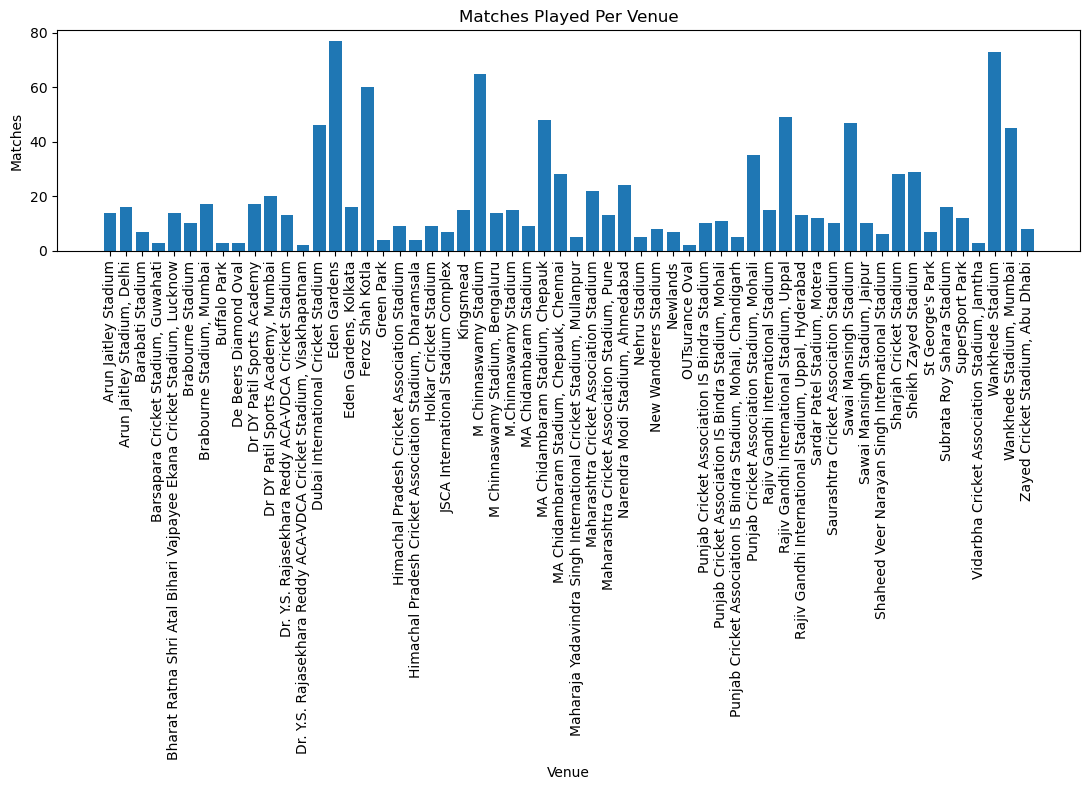

In [44]:
venue_matches = matches.groupby("venue")["match_id"].count()

plt.figure(figsize=(11,8))

plt.bar(
    venue_matches.index,
    venue_matches.values
)

plt.xticks(rotation=90)

plt.title("Matches Played Per Venue")

plt.xlabel("Venue")
plt.ylabel("Matches")

plt.tight_layout()
plt.savefig("../images/matches_per_Venue.png", dpi=300)
plt.show()